# 🏦 Home Credit Default Risk
## Phase 3A — Feature Engineering: Application Table (Layer 1)

> **Goal:** Extract every signal from `application_train/test.csv` before touching
> the supplementary tables. Run CV after this notebook alone to measure the AUC delta.
>
> **Rule:** One feature group at a time. Measure after each group.

---

## 📦 0. Imports & Config

In [1]:
import numpy as np
import pandas as pd
import gc
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline       import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics         import roc_auc_score
from sklearn.preprocessing   import OrdinalEncoder
from sklearn.base            import BaseEstimator, TransformerMixin

import lightgbm as lgb

RANDOM_STATE = 42
N_FOLDS      = 5
DATA_PATH    = '/kaggle/input/competitions/home-credit-default-risk/'
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
print('✅ Imports done')

✅ Imports done


## 1. Utility Functions

In [2]:
def reduce_memory(df, verbose=True):
    """
    Downcast numeric columns to smallest valid dtype.
    Typically cuts memory by 40-60%.
    
    Real-world note: Always do this on load in Kaggle kernels.
    The full dataset can exceed 10GB without downcasting.
    """
    start_mem = df.memory_usage(deep=True).sum() / 1e6
    for col in df.columns:
        col_type = df[col].dtype
        if col_type != object:
            c_min, c_max = df[col].min(), df[col].max()
            if str(col_type)[:3] == 'int':
                for dtype in [np.int8, np.int16, np.int32]:
                    if c_min > np.iinfo(dtype).min and c_max < np.iinfo(dtype).max:
                        df[col] = df[col].astype(dtype)
                        break
            else:
                if c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
    end_mem = df.memory_usage(deep=True).sum() / 1e6
    if verbose:
        print(f'  Memory: {start_mem:.1f} MB → {end_mem:.1f} MB '
              f'({100*(start_mem-end_mem)/start_mem:.1f}% reduction)')
    return df


def run_cv(X, y, params, n_folds=5, label='experiment'):
    """
    Reusable 5-fold stratified CV runner.
    Returns OOF predictions, OOF AUC, fold AUCs.
    
    Use this after EVERY feature group addition.
    Record the result in experiment_log before moving on.
    """
    skf       = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=RANDOM_STATE)
    oof_preds = np.zeros(len(X))
    fold_aucs = []

    for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        model = lgb.LGBMClassifier(**params)
        model.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[
                lgb.early_stopping(100, verbose=False),
                lgb.log_evaluation(-1)
            ]
        )
        oof_preds[val_idx] = model.predict_proba(X_val)[:, 1]
        fold_aucs.append(roc_auc_score(y_val, oof_preds[val_idx]))

    oof_auc = roc_auc_score(y, oof_preds)
    print(f'  [{label}] OOF AUC: {oof_auc:.6f} | '
          f'Mean: {np.mean(fold_aucs):.6f} ± {np.std(fold_aucs):.6f}')
    return oof_preds, oof_auc, fold_aucs


# Shared LightGBM params — same as Phase 2 baseline
LGB_PARAMS = {
    'objective'        : 'binary',
    'metric'           : 'auc',
    'n_estimators'     : 2000,
    'learning_rate'    : 0.05,
    'num_leaves'       : 31,
    'min_child_samples': 20,
    'subsample'        : 0.8,
    'colsample_bytree' : 0.8,
    'reg_lambda'       : 1.0,
    'n_jobs'           : -1,
    'random_state'     : RANDOM_STATE,
    'verbose'          : -1,
}

print('✅ Utilities defined')

✅ Utilities defined


## 2. Load & Fix Anomalies

In [3]:
print('Loading data...')
train = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
test  = pd.read_csv(DATA_PATH + 'application_test.csv')
print(f'  Train: {train.shape} | Test: {test.shape}')

train = reduce_memory(train)
test  = reduce_memory(test)

# ── Fix known anomalies ───────────────────────────────────────────────────────
# DAYS_EMPLOYED = 365243 → sentinel for unemployed/retired
for df in [train, test]:
    df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
    df['CODE_GENDER']   = df['CODE_GENDER'].replace('XNA', np.nan)

y = train['TARGET'].copy()
print(f'\nTarget distribution: {y.value_counts(normalize=True).mul(100).round(1).to_dict()}')

Loading data...
  Train: (307511, 122) | Test: (48744, 121)
  Memory: 529.5 MB → 363.8 MB (31.3% reduction)
  Memory: 83.6 MB → 57.6 MB (31.0% reduction)

Target distribution: {0: 91.9, 1: 8.1}


## 3. Preprocessing Pipeline (Carry-over from Phase 2)

In [4]:
class CategoricalEncoder(BaseEstimator, TransformerMixin):
    """Ordinal-encode all object columns. Safe for train/test."""
    def __init__(self):
        self.encoder  = OrdinalEncoder(
            handle_unknown='use_encoded_value',
            unknown_value=-1,
            encoded_missing_value=-2
        )
        self.cat_cols_ = []

    def fit(self, X, y=None):
        self.cat_cols_ = X.select_dtypes(include='object').columns.tolist()
        if self.cat_cols_:
            self.encoder.fit(X[self.cat_cols_])
        return self

    def transform(self, X):
        X = X.copy()
        if self.cat_cols_:
            X[self.cat_cols_] = self.encoder.transform(X[self.cat_cols_])
        return X


base_pipeline = Pipeline([
    ('encode_cats', CategoricalEncoder()),
])

print('✅ Preprocessing pipeline ready')

✅ Preprocessing pipeline ready


## 4. Feature Engineering — Application Table

> Each feature group is isolated in its own function.
> This makes it easy to add/remove groups and measure impact independently.

### 4.1 — Credit & Income Ratios

In [5]:
def add_credit_income_ratios(df):
    """
    Ratio features derived from credit, income, and annuity amounts.

    Why ratios beat raw values:
      A $50K loan means something very different for someone earning $30K
      vs. $300K. The ratio captures the relative burden.
      
    These mirror what loan officers compute manually (debt-to-income ratio
    is a legally recognized underwriting criterion in most countries).
    """
    df = df.copy()

    # How large is the loan relative to annual income?
    df['CREDIT_INCOME_RATIO']    = df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)

    # Monthly payment burden as % of income
    df['ANNUITY_INCOME_RATIO']   = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + 1)

    # How quickly are they repaying? (higher = faster)
    df['CREDIT_TERM']            = df['AMT_ANNUITY'] / (df['AMT_CREDIT'] + 1)

    # Loan-to-value ratio — how much extra are they borrowing beyond goods price?
    df['GOODS_CREDIT_RATIO']     = df['AMT_GOODS_PRICE'] / (df['AMT_CREDIT'] + 1)

    # Income per family member — family financial pressure
    df['INCOME_PER_PERSON']      = df['AMT_INCOME_TOTAL'] / (df['CNT_FAM_MEMBERS'] + 1)

    # Loan amount per family member
    df['CREDIT_PER_PERSON']      = df['AMT_CREDIT'] / (df['CNT_FAM_MEMBERS'] + 1)

    # Down payment proxy — difference between goods price and credit
    df['AMT_DOWN_PAYMENT_PROXY'] = df['AMT_GOODS_PRICE'] - df['AMT_CREDIT']

    return df


print('✅ Credit/income ratio functions defined')

# Preview new features
sample = add_credit_income_ratios(train.head())
new_cols = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
            'GOODS_CREDIT_RATIO', 'INCOME_PER_PERSON', 'CREDIT_PER_PERSON',
            'AMT_DOWN_PAYMENT_PROXY']
sample[new_cols]

✅ Credit/income ratio functions defined


,CREDIT_INCOME_RATIO,ANNUITY_INCOME_RATIO,CREDIT_TERM,GOODS_CREDIT_RATIO,INCOME_PER_PERSON,CREDIT_PER_PERSON,AMT_DOWN_PAYMENT_PROXY
0,2.007879,0.121977,0.060749,0.863259,101250.0,203298.75,-55597.5
1,4.790732,0.132216,0.027598,0.873210,90000.0,431167.50,-164002.5
2,1.999970,0.099999,0.050000,0.999993,33750.0,67500.00,0.0
3,2.316149,0.219898,0.094941,0.949842,45000.0,104227.50,-15682.5
4,4.222188,0.179961,0.042623,0.999998,60750.0,256500.00,0.0


### 4.2 — Age & Employment Features

In [6]:
def add_age_employment_features(df):
    """
    Time-based features from DAYS_ columns.

    DAYS_* are stored as negative integers (days before application).
    We convert to positive years for interpretability and create
    interaction features that capture employment stability.

    Real-world insight:
      A 25-year-old employed for 3 years is very different from a
      50-year-old employed for 3 years. The ratio captures this.
    """
    df = df.copy()

    # Convert days to years (positive)
    df['AGE_YEARS']               = df['DAYS_BIRTH']        / -365
    df['EMPLOYED_YEARS']          = df['DAYS_EMPLOYED']     / -365   # NaN for unemployed
    df['REGISTRATION_YEARS']      = df['DAYS_REGISTRATION'] / -365
    df['ID_PUBLISH_YEARS']        = df['DAYS_ID_PUBLISH']   / -365
    df['LAST_PHONE_CHANGE_YEARS'] = df['DAYS_LAST_PHONE_CHANGE'] / -365

    # What fraction of their life have they been employed?
    # High ratio = stable employment history
    df['EMPLOYED_TO_AGE_RATIO']   = df['EMPLOYED_YEARS'] / (df['AGE_YEARS'] + 1)

    # How long ago did they register their address vs their age?
    # Very recent registration on an old person might be a flag
    df['REGISTRATION_TO_AGE']     = df['REGISTRATION_YEARS'] / (df['AGE_YEARS'] + 1)

    # How old is their ID document relative to their age?
    df['ID_TO_AGE_RATIO']         = df['ID_PUBLISH_YEARS'] / (df['AGE_YEARS'] + 1)

    # Age at which they started their current job
    df['AGE_AT_EMPLOYMENT_START'] = df['AGE_YEARS'] - df['EMPLOYED_YEARS']

    return df


print('✅ Age/employment functions defined')

✅ Age/employment functions defined


### 4.3 — EXT_SOURCE Interactions (Most Powerful Features)

In [7]:
def add_ext_source_features(df):
    """
    Interaction features between the three external credit scores.

    EXT_SOURCE_1/2/3 are scores from external credit bureaus.
    Higher = better creditworthiness. They measure different aspects
    of credit history and together are the strongest signal in this dataset.

    Why interactions?
      Someone with EXT_SOURCE_2=0.8 but EXT_SOURCE_1=0.2 is different
      from someone with both at 0.5. The combination matters.

    Real-world note:
      In production credit scoring, combining multiple bureau scores
      (e.g., FICO, VantageScore, bureau-specific scores) is standard
      practice. The ensemble of scores is more predictive than any one.
    """
    df = df.copy()
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

    # Simple statistics across the three scores
    df['EXT_SOURCE_MEAN']    = df[ext_cols].mean(axis=1)          # Average score
    df['EXT_SOURCE_STD']     = df[ext_cols].std(axis=1)           # Consistency of scores
    df['EXT_SOURCE_MIN']     = df[ext_cols].min(axis=1)           # Worst score
    df['EXT_SOURCE_MAX']     = df[ext_cols].max(axis=1)           # Best score
    df['EXT_SOURCE_RANGE']   = df['EXT_SOURCE_MAX'] - df['EXT_SOURCE_MIN']  # Spread

    # Product — rewards consistently high scores, heavily penalizes any low one
    df['EXT_SOURCE_PRODUCT'] = df['EXT_SOURCE_1'] * df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

    # Weighted mean — EXT_SOURCE_2 tends to be most predictive
    df['EXT_SOURCE_WEIGHTED'] = (
        df['EXT_SOURCE_1'].fillna(df['EXT_SOURCE_MEAN']) * 0.5  +
        df['EXT_SOURCE_2'].fillna(df['EXT_SOURCE_MEAN']) * 2.0  +
        df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_MEAN']) * 1.5
    ) / 4.0

    # How many scores are available? Missing score = likely no credit history
    df['EXT_SOURCE_COUNT']   = df[ext_cols].notna().sum(axis=1)

    # Pairwise interactions
    df['EXT_12_RATIO']       = df['EXT_SOURCE_1'] / (df['EXT_SOURCE_2'] + 1e-5)
    df['EXT_23_RATIO']       = df['EXT_SOURCE_2'] / (df['EXT_SOURCE_3'] + 1e-5)
    df['EXT_13_RATIO']       = df['EXT_SOURCE_1'] / (df['EXT_SOURCE_3'] + 1e-5)

    # Missing indicators — missingness itself is a signal
    for col in ext_cols:
        df[f'{col}_MISSING'] = df[col].isnull().astype(np.int8)

    # EXT_SOURCE combined with credit burden
    # Low credit score + high loan burden = very high risk
    df['EXT_MEAN_X_CREDIT_RATIO'] = df['EXT_SOURCE_MEAN'] * (
        df['AMT_CREDIT'] / (df['AMT_INCOME_TOTAL'] + 1)
    )

    return df


print('✅ EXT_SOURCE interaction functions defined')

✅ EXT_SOURCE interaction functions defined


### 4.4 — Social, Regional & Document Features

In [8]:
def add_social_document_features(df):
    """
    Features from social circle, regional risk, and document submission.

    Social circle default rates:
      If your social network has high default rates, you are statistically
      at higher risk yourself. This is a controversial but predictive signal.
      Flag for fairness review in production.

    Document count:
      20 individual FLAG_DOCUMENT columns exist. Individually they're weak.
      Combined into a count, they capture 'how thorough is this application?'
      Low document count can indicate urgency or less organized applicant.
    """
    df = df.copy()

    # ── Social circle defaults ────────────────────────────────────────────────
    # Total defaults in social circle
    df['SOCIAL_CIRCLE_DEFAULT_TOTAL'] = (
        df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(0) +
        df['DEF_60_CNT_SOCIAL_CIRCLE'].fillna(0)
    )
    # Default rate in social circle (observed / total)
    df['SOCIAL_CIRCLE_DEFAULT_RATE'] = (
        df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(0) /
        (df['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(1) + 1)
    )

    # ── Regional risk ─────────────────────────────────────────────────────────
    # Average region rating (city + client region)
    df['REGION_RATING_MEAN'] = (
        df['REGION_RATING_CLIENT'] + df['REGION_RATING_CLIENT_W_CITY']
    ) / 2

    # Discrepancy between region and city rating
    df['REGION_CITY_DIFF'] = (
        df['REGION_RATING_CLIENT_W_CITY'] - df['REGION_RATING_CLIENT']
    )

    # ── Document submission ───────────────────────────────────────────────────
    doc_cols = [c for c in df.columns if c.startswith('FLAG_DOCUMENT')]
    df['DOCUMENT_COUNT']    = df[doc_cols].sum(axis=1)
    df['DOCUMENT_MISSING']  = (df[doc_cols].sum(axis=1) == 0).astype(np.int8)

    # ── Contact flags ─────────────────────────────────────────────────────────
    contact_cols = ['FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE',
                    'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL']
    contact_cols = [c for c in contact_cols if c in df.columns]
    df['CONTACT_COUNT'] = df[contact_cols].sum(axis=1)

    # ── Children & family ─────────────────────────────────────────────────────
    df['CHILDREN_RATIO'] = df['CNT_CHILDREN'] / (df['CNT_FAM_MEMBERS'] + 1)
    df['HAS_CHILDREN']   = (df['CNT_CHILDREN'] > 0).astype(np.int8)

    return df


print('✅ Social/document functions defined')

✅ Social/document functions defined


### 4.5 — Missing Value Indicators

In [9]:
def add_missing_indicators(df):
    """
    Binary flags for columns where missingness correlates with default risk.

    Why this matters:
      If we impute EXT_SOURCE_1 with the mean, the model loses information
      about which rows were originally missing. The indicator preserves that.
      
      This is standard practice in production ML pipelines:
      impute + add indicator, never just impute blindly.

    Only add indicators for columns where missingness showed
    meaningful default rate difference in Phase 1 EDA.
    """
    df = df.copy()

    # High-signal missing columns identified in Phase 1 EDA
    signal_cols = [
        'EXT_SOURCE_1',         # 56% missing, higher default when missing
        'EXT_SOURCE_3',         # 19% missing
        'AMT_GOODS_PRICE',      # 0.1% missing but meaningful
        'AMT_ANNUITY',          # Small % but important
        'OWN_CAR_AGE',          # 66% missing = likely no car
        'OCCUPATION_TYPE',      # 31% missing = possible unemployment
        'CNT_FAM_MEMBERS',
        'DAYS_LAST_PHONE_CHANGE',
    ]

    for col in signal_cols:
        if col in df.columns:
            df[f'{col}_MISSING'] = df[col].isnull().astype(np.int8)

    # OWN_CAR_AGE=NaN almost certainly means no car — impute with 0
    if 'OWN_CAR_AGE' in df.columns:
        df['OWN_CAR_AGE'] = df['OWN_CAR_AGE'].fillna(0)

    return df


print('✅ Missing indicator functions defined')

✅ Missing indicator functions defined


## 5. Master Feature Engineering Function

In [10]:
def engineer_application_features(df):
    """
    Master function: applies all Layer 1 feature groups in sequence.

    Called identically on both train and test — no leakage possible
    because all operations are row-wise arithmetic (no statistics
    computed from the training set are embedded here).

    Real-world note:
      Row-wise features (ratios, differences) are always safe.
      Aggregate features (means, encodings) require fit-on-train-only.
      Keep them in separate transformers.
    """
    print(f'  Input shape: {df.shape}')
    df = add_credit_income_ratios(df)
    df = add_age_employment_features(df)
    df = add_ext_source_features(df)
    df = add_social_document_features(df)
    df = add_missing_indicators(df)
    print(f'  Output shape: {df.shape}')
    print(f'  New features added: {df.shape[1] - 122}')
    return df


print('Applying feature engineering to train and test...')
train_fe = engineer_application_features(train)
test_fe  = engineer_application_features(test)
print('\n✅ Feature engineering complete')

Applying feature engineering to train and test...
  Input shape: (307511, 122)
  Output shape: (307511, 168)
  New features added: 46
  Input shape: (48744, 121)
  Output shape: (48744, 167)
  New features added: 45

✅ Feature engineering complete


## 6. Prepare for Modeling

In [11]:
EXCLUDE_COLS = ['TARGET', 'SK_ID_CURR']

# Prepare train features
X = train_fe.drop(columns=EXCLUDE_COLS, errors='ignore')
X_test = test_fe.drop(columns=EXCLUDE_COLS, errors='ignore')

# Align columns (in case test is missing any columns)
X_test = X_test.reindex(columns=X.columns, fill_value=np.nan)

# Encode categoricals
encoder = CategoricalEncoder()
X       = encoder.fit_transform(X)
X_test  = encoder.transform(X_test)

print(f'X shape   : {X.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'\nFeature count increase from baseline: {X.shape[1] - 120}')

X shape   : (307511, 166)
X_test shape: (48744, 166)

Feature count increase from baseline: 46


## 7. Measure AUC Delta — One Group at a Time

> **Discipline:** We measure after each group so we know what's actually helping.

In [12]:
# ── Step-by-step AUC measurement ─────────────────────────────────────────────
# We rebuild X incrementally to isolate the contribution of each feature group.

experiment_log = []

# Baseline columns (from Phase 2)
base_cols = [c for c in X.columns if c in train.columns]

# New feature groups
ratio_cols   = ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM',
                'GOODS_CREDIT_RATIO', 'INCOME_PER_PERSON', 'CREDIT_PER_PERSON',
                'AMT_DOWN_PAYMENT_PROXY']

age_cols     = ['AGE_YEARS', 'EMPLOYED_YEARS', 'EMPLOYED_TO_AGE_RATIO',
                'AGE_AT_EMPLOYMENT_START', 'REGISTRATION_TO_AGE', 'ID_TO_AGE_RATIO']

ext_cols     = [c for c in X.columns if 'EXT_SOURCE' in c and c not in train.columns]

social_cols  = ['SOCIAL_CIRCLE_DEFAULT_TOTAL', 'SOCIAL_CIRCLE_DEFAULT_RATE',
                'REGION_RATING_MEAN', 'DOCUMENT_COUNT', 'CONTACT_COUNT',
                'CHILDREN_RATIO']

missing_cols = [c for c in X.columns if c.endswith('_MISSING')]


def measure_group(current_cols, new_cols, label, log):
    """Add new_cols to current_cols, run CV, log result."""
    new_cols_valid = [c for c in new_cols if c in X.columns]
    combined = list(set(current_cols + new_cols_valid))
    _, auc, fold_aucs = run_cv(X[combined], y, LGB_PARAMS, label=label)
    log.append({
        'experiment'    : label,
        'n_features'    : len(combined),
        'oof_auc'       : round(auc, 6),
        'std'           : round(np.std(fold_aucs), 6),
        'new_features'  : len(new_cols_valid)
    })
    return combined


print('Running incremental AUC measurements...\n')

# 1. Baseline features only
active_cols = base_cols
_, auc_base, fold_aucs_base = run_cv(X[active_cols], y, LGB_PARAMS, label='01_baseline_cols')
experiment_log.append({'experiment': '01_baseline_cols', 'n_features': len(active_cols),
                        'oof_auc': round(auc_base, 6), 'std': round(np.std(fold_aucs_base), 6),
                        'new_features': 0})

# 2. + Ratio features
active_cols = measure_group(active_cols, ratio_cols, '02_+credit_ratios', experiment_log)

# 3. + Age/employment features
active_cols = measure_group(active_cols, age_cols, '03_+age_employment', experiment_log)

# 4. + EXT_SOURCE interactions
active_cols = measure_group(active_cols, ext_cols, '04_+ext_source_interactions', experiment_log)

# 5. + Social/document features
active_cols = measure_group(active_cols, social_cols, '05_+social_document', experiment_log)

# 6. + Missing indicators
active_cols = measure_group(active_cols, missing_cols, '06_+missing_indicators', experiment_log)

Running incremental AUC measurements...

  [01_baseline_cols] OOF AUC: 0.759660 | Mean: 0.759703 ± 0.003913
  [02_+credit_ratios] OOF AUC: 0.768407 | Mean: 0.768431 ± 0.004335
  [03_+age_employment] OOF AUC: 0.768315 | Mean: 0.768350 ± 0.004194
  [04_+ext_source_interactions] OOF AUC: 0.767252 | Mean: 0.767271 ± 0.003982
  [05_+social_document] OOF AUC: 0.768167 | Mean: 0.768251 ± 0.004064
  [06_+missing_indicators] OOF AUC: 0.767932 | Mean: 0.767974 ± 0.003918



📋 Phase 3A Experiment Log:
                 experiment  n_features  oof_auc      std  new_features  auc_delta
           01_baseline_cols         120 0.759660 0.003913             0   0.000000
          02_+credit_ratios         127 0.768407 0.004335             7   0.008747
         03_+age_employment         133 0.768315 0.004194             6  -0.000092
04_+ext_source_interactions         144 0.767252 0.003982            11  -0.001063
        05_+social_document         150 0.768167 0.004064             6   0.000915
     06_+missing_indicators         157 0.767932 0.003918            10  -0.000235


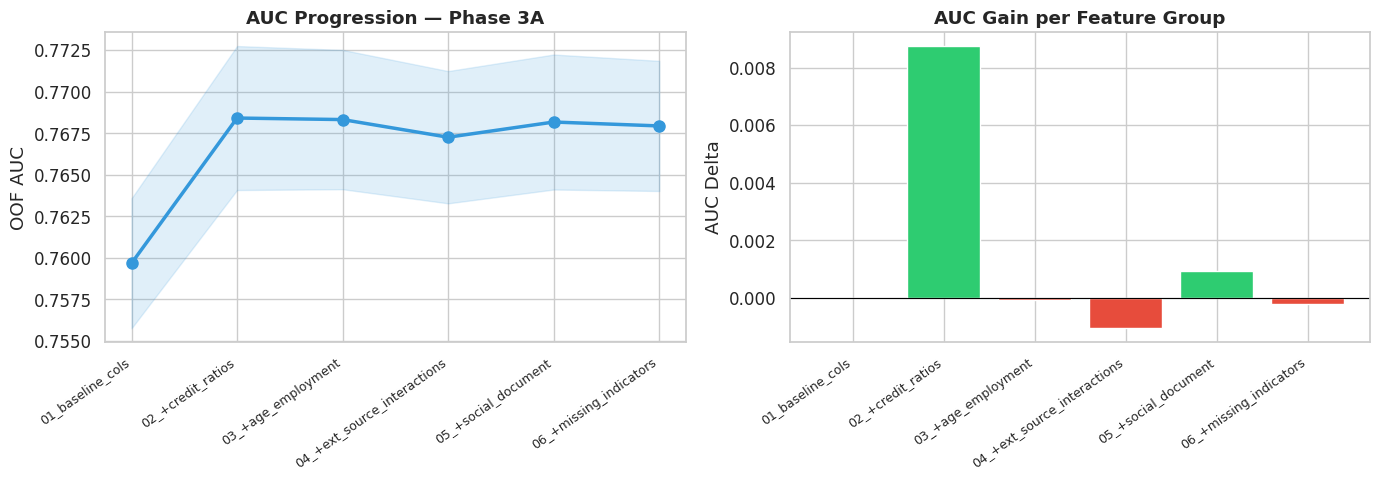

In [13]:
# ── Experiment Log ────────────────────────────────────────────────────────────
log_df = pd.DataFrame(experiment_log)
log_df['auc_delta'] = log_df['oof_auc'].diff().round(6)
log_df['auc_delta'].iloc[0] = 0.0

print('\n📋 Phase 3A Experiment Log:')
print(log_df.to_string(index=False))

# Plot AUC progression
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(log_df['experiment'], log_df['oof_auc'], 'o-', color='#3498db',
             linewidth=2.5, markersize=8)
axes[0].fill_between(range(len(log_df)),
                      log_df['oof_auc'] - log_df['std'],
                      log_df['oof_auc'] + log_df['std'],
                      alpha=0.15, color='#3498db')
axes[0].set_xticklabels(log_df['experiment'], rotation=35, ha='right', fontsize=9)
axes[0].set_ylabel('OOF AUC')
axes[0].set_title('AUC Progression — Phase 3A', fontweight='bold')

colors_delta = ['#2ecc71' if x >= 0 else '#e74c3c' for x in log_df['auc_delta']]
axes[1].bar(log_df['experiment'], log_df['auc_delta'], color=colors_delta)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_xticklabels(log_df['experiment'], rotation=35, ha='right', fontsize=9)
axes[1].set_ylabel('AUC Delta')
axes[1].set_title('AUC Gain per Feature Group', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Save Engineered Features

In [14]:
# Save the full engineered train and test for Phase 3B
# Phase 3B will merge supplementary table aggregations onto these

train_fe['TARGET'] = y  # Re-attach target

train_fe.to_parquet('train_phase3a.parquet', index=False)
test_fe.to_parquet('test_phase3a.parquet',   index=False)

print(f'✅ Saved train_phase3a.parquet : {train_fe.shape}')
print(f'✅ Saved test_phase3a.parquet  : {test_fe.shape}')
print('\n→ Load these in Phase 3B notebook to continue building features.')

✅ Saved train_phase3a.parquet : (307511, 168)
✅ Saved test_phase3a.parquet  : (48744, 167)

→ Load these in Phase 3B notebook to continue building features.
